<a href="https://colab.research.google.com/github/brandy99swords/AIML2003_NLP/blob/main/AIML2003_lab6_InventoryReportAgent.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# Cell 1: Setup  
  
Notes: gemini-1.5-flash and gemini-2.0-flash provided too many errors so I used gemini-2.5-flash

Gemini API and CSV data source are hidden in keys

In [2]:
import warnings
warnings.filterwarnings("ignore")

# Install the required Google GenAI SDK
!pip install -q google-genai

# Required Gemini SDK imports
from google import genai
from google.genai import types

# General libraries used throughout the notebook
import json
import datetime
import math
import textwrap
import time
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Markdown, display
from google.colab import userdata
import re
from google.protobuf import json_format

# Configure the Gemini API key from Colab Secrets
GEMINI_API_KEY = userdata.get('GEMINI_API_KEY')

client = genai.Client(api_key=GEMINI_API_KEY)

MODEL_ID = "gemini-2.5-flash"

# Test prompt to confirm connection
try:
    response = client.models.generate_content(
        model=MODEL_ID,
        contents="Hello, Gemini!"
    )
    print(f"Gemini API connection successful! Test response: {response.text}")
except Exception as e:
    print(f"Error connecting to Gemini API: {e}")
    print("Please check your API key and MODEL_ID.")

# Retrieve INK_INVENTORY file path from Colab Secrets
INK_INVENTORY_VIEW_LINK = userdata.get('INK_INVENTORY')

# Extract file ID from the view link
file_id_match = re.search(r'/d/([a-zA-Z0-9_-]+)', INK_INVENTORY_VIEW_LINK)
if file_id_match:
    file_id = file_id_match.group(1)
    INK_INVENTORY = f"https://drive.google.com/uc?export=download&id={file_id}"
else:
    INK_INVENTORY = INK_INVENTORY_VIEW_LINK  # Fallback if ID extraction fails
    print("Warning: Could not extract file ID from Google Drive link. Attempting to use original link.")

print(f"\nUsing MODEL_ID: {MODEL_ID}")

print("Inventory Data:")
try:
    # Read the CSV directly from the Google Drive direct download link.
    inventory_df = pd.read_csv(INK_INVENTORY)
    print("Successfully loaded CSV file. Displaying first 5 rows and first 5 columns:")
    display(inventory_df.head().iloc[:, :5])
except Exception as e:
    print(f"Error loading CSV file from {INK_INVENTORY}: {e}")
    print("Please ensure the direct download file path is correct and accessible.")

Gemini API connection successful! Test response: Hello there! How can I help you today?

Using MODEL_ID: gemini-2.5-flash
Inventory Data:
Successfully loaded CSV file. Displaying first 5 rows and first 5 columns:


,Ink / Part #,2025-05-12,2025-05-26,2025-06-09,2025-06-23
0,Epson UltraChrome HD Photo Black - P# EPS-T913100,0,1,1,0
1,Epson UltraChrome HD Cyan - P# EPS-T913200,0,0,2,3
2,Epson UltraChrome HD Vivid Magenta - P# EPS-T9...,0,1,0,0
3,Epson UltraChrome HD Yellow - P# EPS-T913400,2,0,3,2
4,Epson UltraChrome HD Light Cyan - P# EPS-T913500,1,2,0,2


# Cell 2: Define Tool Functions  
  
This cell defines the tool functions used by the agent, including calculator, datetime, knowledge lookup, and inventory graphing. These functions allow the agent to perform calculations, retrieve current date/time, query the inventory CSV, and generate visual reports.  
  
Why is it important to restrict what eval() can execute?  
It is important to restrict what eval() can execute because eval() runs Python code from a string.  
  
What could happen if you passed user input directly to an unrestricted eval()?  
If user input is passed directly into unrestricted eval(), the user could run unsafe code, access files, import modules, or execute system commands. In this project, eval() is restricted by removing built-ins and only allowing access to the math module, so the calculator can evaluate math expressions without giving the user access to the full Python environment.

Testing calculator function:
5 + 3 * 2 = 11 


Testing get_datetime function:
Current datetime: Tuesday, May 05, 2026, 10:12 PM 


Testing knowledge_lookup function:
Inventory Report for: 'EPS-T913100'
Date Range: from 2025-05-01 to 2025-05-31
----------------------------------------
 Epson UltraChrome HD Photo Black - P# EPS-T913100: Total Quantity = 1
----------------------------------------
Total Quantity for 'EPS-T913100': 1 

Inventory Report for: 'Black Ink'
----------------------------------------
 Epson UltraChrome HD Photo Black - P# EPS-T913100: Total Quantity = 21
 Epson UltraChrome HD Light Black - P# EPS-T913700: Total Quantity = 21
 Epson UltraChrome HD Matte Black - P# EPS-T913800: Total Quantity = 17
 Epson UltraChrome HD Light Light Black - P# EPS-T913900: Total Quantity = 25
 Canon Lucia Pro Photo Black - P# CAN-PFI1700PBK: Total Quantity = 25
 Canon Lucia Pro Matte Black - P# CAN-PFI1700MBK: Total Quantity = 21
 HP Indigo ElectroInk Black - P# HP-Q4400A: Total Quanti

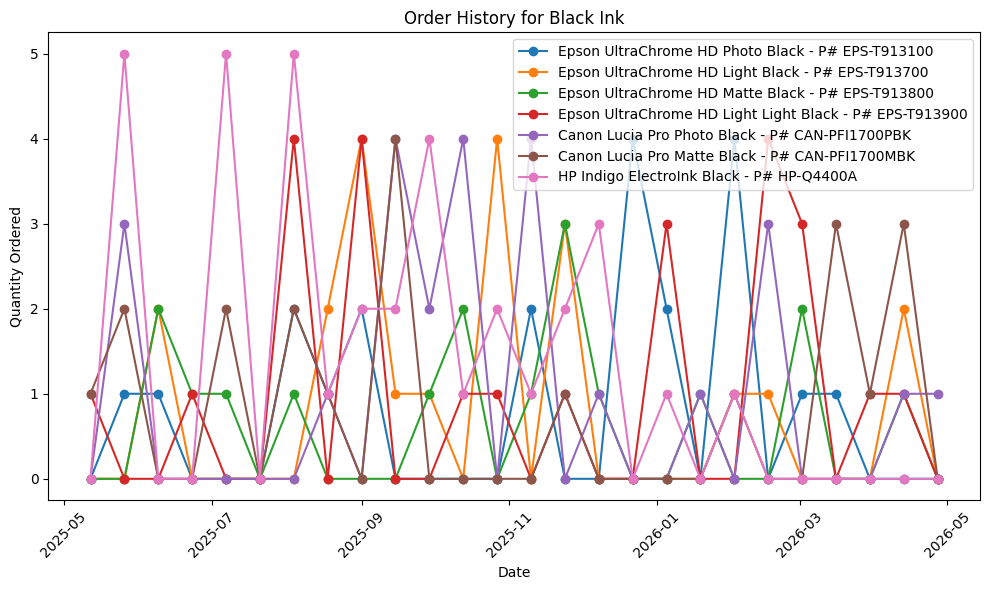

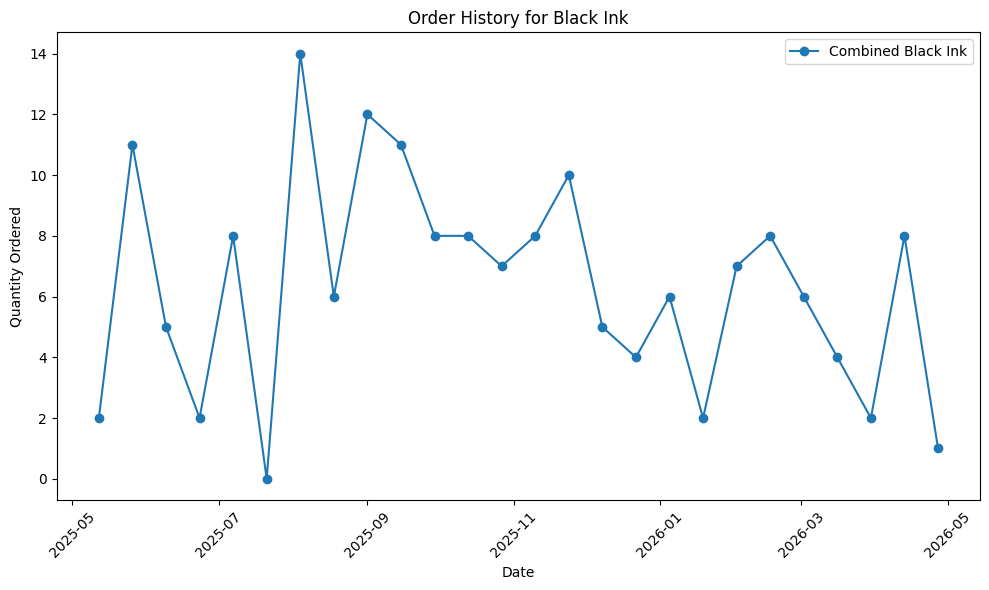

"Graph created for 'Black Ink'."

In [3]:
def calculator(expression: str) -> str:
    try:
        safe_dict = {"__builtins__": {}, "math": math}
        result = eval(expression, safe_dict, safe_dict)
        return str(result)
    except Exception as e:
        return f"Error: Invalid expression - {e}"


def get_datetime() -> str:
    now = datetime.datetime.now()
    return now.strftime("%A, %B %d, %Y, %I:%M %p %Z").strip()


def knowledge_lookup(topic: str, start_date_str: str = None, end_date_str: str = None) -> str:
    if "inventory_df" not in globals():
        return "Error: inventory_df not found. Please ensure it was loaded in Cell 1."

    if not topic:
        return "Error: A topic is required to look up inventory information."

    clean_topic = topic.replace("ink", "").replace("Ink", "").strip()

    df_filtered = inventory_df.copy()
    item_column = "Ink / Part #"

    date_columns = [col for col in df_filtered.columns if col != item_column]
    date_columns_as_dates = pd.to_datetime(date_columns, errors="coerce")

    valid_date_columns = [
        date_columns[index]
        for index, date_value in enumerate(date_columns_as_dates)
        if pd.notna(date_value)
    ]

    valid_date_values = [
        date_value
        for date_value in date_columns_as_dates
        if pd.notna(date_value)
    ]

    if start_date_str:
        start_date = pd.to_datetime(start_date_str)
    else:
        start_date = None

    if end_date_str:
        end_date = pd.to_datetime(end_date_str)
    else:
        end_date = None

    filtered_date_columns = []
    for column_name, date_value in zip(valid_date_columns, valid_date_values):
        if start_date is not None and date_value < start_date:
            continue
        if end_date is not None and date_value > end_date:
            continue
        filtered_date_columns.append(column_name)

    if not filtered_date_columns:
        return "No inventory data available for the specified date range."

    df_report = df_filtered[[item_column] + filtered_date_columns]
    df_report = df_report[df_report[item_column].str.contains(clean_topic, case=False, na=False)]

    if df_report.empty:
        return f"No information available for: {topic}"

    report_lines = []
    report_lines.append(f"Inventory Report for: '{topic}'")

    if start_date_str or end_date_str:
        date_range_info = []
        if start_date_str:
            date_range_info.append(f"from {start_date_str}")
        if end_date_str:
            date_range_info.append(f"to {end_date_str}")
        report_lines.append(f"Date Range: {' '.join(date_range_info)}")

    report_lines.append("-" * 40)

    for index, row in df_report.iterrows():
        item_name = row[item_column]
        total_quantity = row[filtered_date_columns].apply(pd.to_numeric, errors="coerce").sum()
        report_lines.append(f" {item_name}: Total Quantity = {int(total_quantity) if pd.notna(total_quantity) else 'N/A'}")

    overall_total = df_report[filtered_date_columns].apply(pd.to_numeric, errors="coerce").sum().sum()

    report_lines.append("-" * 40)
    report_lines.append(f"Total Quantity for '{topic}': {int(overall_total) if pd.notna(overall_total) else 'N/A'}")

    return "\n".join(report_lines)


def inventory_graph(topic: str, start_date_str: str = None, end_date_str: str = None, combine_matches: bool = False) -> str:
    if "inventory_df" not in globals():
        return "Error: inventory_df not found. Please ensure it was loaded in Cell 1."

    if not topic:
        return "Error: A topic is required to graph inventory information."

    clean_topic = topic.replace("ink", "").replace("Ink", "").strip()

    df_filtered = inventory_df.copy()
    item_column = "Ink / Part #"

    date_columns = [col for col in df_filtered.columns if col != item_column]
    date_columns_as_dates = pd.to_datetime(date_columns, errors="coerce")

    valid_date_columns = [
        date_columns[index]
        for index, date_value in enumerate(date_columns_as_dates)
        if pd.notna(date_value)
    ]

    valid_date_values = [
        date_value
        for date_value in date_columns_as_dates
        if pd.notna(date_value)
    ]

    if start_date_str:
        start_date = pd.to_datetime(start_date_str)
    else:
        start_date = None

    if end_date_str:
        end_date = pd.to_datetime(end_date_str)
    else:
        end_date = None

    filtered_date_columns = []
    filtered_date_values = []

    for column_name, date_value in zip(valid_date_columns, valid_date_values):
        if start_date is not None and date_value < start_date:
            continue
        if end_date is not None and date_value > end_date:
            continue
        filtered_date_columns.append(column_name)
        filtered_date_values.append(date_value)

    if not filtered_date_columns:
        return "No inventory data available for the specified date range."

    df_graph = df_filtered[[item_column] + filtered_date_columns]
    df_graph = df_graph[df_graph[item_column].str.contains(clean_topic, case=False, na=False)]

    if df_graph.empty:
        return f"No information available for: {topic}"

    df_graph[filtered_date_columns] = df_graph[filtered_date_columns].apply(pd.to_numeric, errors="coerce").fillna(0)

    plt.figure(figsize=(10, 6))

    if combine_matches:
        combined_totals = df_graph[filtered_date_columns].sum()
        plt.plot(filtered_date_values, combined_totals, marker="o", label=f"Combined {topic}")
    else:
        for index, row in df_graph.iterrows():
            plt.plot(filtered_date_values, row[filtered_date_columns], marker="o", label=row[item_column])

    plt.xlabel("Date")
    plt.ylabel("Quantity Ordered")
    plt.title(f"Order History for {topic}")
    plt.xticks(rotation=45)
    plt.legend()
    plt.tight_layout()
    plt.show()

    return f"Graph created for '{topic}'."


TOOL_FUNCTIONS = {
    "calculator": calculator,
    "get_datetime": get_datetime,
    "knowledge_lookup": knowledge_lookup,
    "inventory_graph": inventory_graph,
}


print("Testing calculator function:")
print(f"5 + 3 * 2 = {calculator('5 + 3 * 2')}", "\n")

print("\nTesting get_datetime function:")
print(f"Current datetime: {get_datetime()}", "\n")

print("\nTesting knowledge_lookup function:")
print(knowledge_lookup("EPS-T913100", "2025-05-01", "2025-05-31"), "\n")
print(knowledge_lookup("Black Ink"), "\n")
print(knowledge_lookup("EPS-T913200", "2025-06-01", "2025-07-01"), "\n")

print("\nTesting inventory_graph function:")
inventory_graph("Black Ink")
inventory_graph("Black Ink combined")
inventory_graph("Black Ink", combine_matches=True)

# Cell 3: Define Tool Schemas for Gemini  
  
How would you test whether your descriptions are good enough?  
I will be testing the tool descriptions by asking several sample questions that clearly belong to each tool and checking whether Gemini routes them correctly.

What would happen if two tools had overlapping descriptions?
If two tools had overlapping descriptions, the model might choose the wrong tool or become inconsistent. For example, if both knowledge_lookup and inventory_graph were described as “summarizing inventory data,” Gemini might call the graph tool when the user only wants a text report, or call the lookup tool when the user asks for a chart. Clear, specific descriptions help the model decide which tool matches the user’s request.  
  
**Note: I also used function declarations to help the LLM discern what functions to use and when.**

In [4]:
calculator_parameters = {
    "type": "object",
    "properties": {
        "expression": {
            "type": "string",
            "description": "The mathematical expression to evaluate, such as '2 + 3 * 4'."
        }
    },
    "required": ["expression"]
}

get_datetime_parameters = {
    "type": "object",
    "properties": {}
}

knowledge_lookup_parameters = {
    "type": "object",
    "properties": {
        "topic": {
            "type": "string",
            "description": "The part number, ink name, or descriptive text to search for in the 'Ink / Part #' column."
        },
        "start_date_str": {
            "type": "string",
            "description": "Optional start date for the report in YYYY-MM-DD format."
        },
        "end_date_str": {
            "type": "string",
            "description": "Optional end date for the report in YYYY-MM-DD format."
        }
    },
    "required": ["topic"]
}

inventory_graph_parameters = {
    "type": "object",
    "properties": {
        "topic": {
            "type": "string",
            "description": "The part number, ink name, or descriptive text to graph from the 'Ink / Part #' column."
        },
        "start_date_str": {
            "type": "string",
            "description": "Optional start date for the graph in YYYY-MM-DD format."
        },
        "end_date_str": {
            "type": "string",
            "description": "Optional end date for the graph in YYYY-MM-DD format."
        },
        "combine_matches": {
            "type": "boolean",
            "description": "Set to true when the user asks to combine all matching inks into one line on the graph. Set to false when the user asks to show each matching ink separately."
        }
    },
    "required": ["topic"]
}


# Create Function Declarations

calculator_tool = types.FunctionDeclaration(
    name="calculator",
    description="Use this tool to evaluate a mathematical expression.",
    parameters=calculator_parameters
)

get_datetime_tool = types.FunctionDeclaration(
    name="get_datetime",
    description="Use this tool to get the current date and time.",
    parameters=get_datetime_parameters
)

knowledge_lookup_tool = types.FunctionDeclaration(
    name="knowledge_lookup",
    description="Use this tool to look up and summarize inventory data from the CSV file based on a part number or description, with optional date filtering.",
    parameters=knowledge_lookup_parameters
)

inventory_graph_tool = types.FunctionDeclaration(
    name="inventory_graph",
    description="Use this tool to create a graph of inventory order history from the CSV file. Use combine_matches=True when the user asks for all matching inks combined into one line.",
    parameters=inventory_graph_parameters
)


# Create tools list

tools = [
    types.Tool(
        function_declarations=[
            calculator_tool,
            get_datetime_tool,
            knowledge_lookup_tool,
            inventory_graph_tool
        ]
    )
]


# Print readable schema (REQUIRED)

print("Tool Declarations (Readable):")

readable_tools = {
    "calculator": calculator_parameters,
    "get_datetime": get_datetime_parameters,
    "knowledge_lookup": knowledge_lookup_parameters,
    "inventory_graph": inventory_graph_parameters
}

print(json.dumps(readable_tools, indent=2))

Tool Declarations (Readable):
{
  "calculator": {
    "type": "object",
    "properties": {
      "expression": {
        "type": "string",
        "description": "The mathematical expression to evaluate, such as '2 + 3 * 4'."
      }
    },
    "required": [
      "expression"
    ]
  },
  "get_datetime": {
    "type": "object",
    "properties": {}
  },
  "knowledge_lookup": {
    "type": "object",
    "properties": {
      "topic": {
        "type": "string",
        "description": "The part number, ink name, or descriptive text to search for in the 'Ink / Part #' column."
      },
      "start_date_str": {
        "type": "string",
        "description": "Optional start date for the report in YYYY-MM-DD format."
      },
      "end_date_str": {
        "type": "string",
        "description": "Optional end date for the report in YYYY-MM-DD format."
      }
    },
    "required": [
      "topic"
    ]
  },
  "inventory_graph": {
    "type": "object",
    "properties": {
      "topic

# Cell 4: Build the Agent Loop  
  
How many API calls did it take?  
2  
  
Why does the model need to be called twice — once to decide to use the tool, and again to incorporate the tool's result?  
It takes two API calls when a tool is used. The first call lets the model decide if it needs a tool and which one to use. The second call happens after the tool runs so the model can use that result to generate the final response.

In [6]:
chat_history = []
question_log = []
response_log = []

SYSTEM_INSTRUCTION = (
    "You are an inventory reporting assistant that works with a CSV-based knowledge base of ink orders. "
    "The CSV contains an 'Ink / Part #' column with part numbers and descriptions, and date columns representing quantities ordered on specific dates. "
    "Your primary goal is to answer user questions by generating summary reports from this inventory data. "
    "Use the knowledge_lookup tool to retrieve and summarize inventory data. "
    "This includes searching by part number, ink name, or descriptive text, and optionally filtering by date ranges. "
    "Use prior conversation context to resolve follow-up requests such as 'that', 'those results', or 'the previous answer'. "
    "Examples of valid tasks include calculating total quantities for a part number, summarizing all items matching a keyword, "
    "or reporting quantities within a specific date range. "
    "Use the calculator tool only when mathematical calculations are required beyond what knowledge_lookup provides. "
    "Use get_datetime only when the user asks for the current date or time. "
    "Do not guess inventory values. Always use knowledge_lookup when answering questions about the CSV data. "
    "If a tool returns an error, clearly explain the error to the user. "
    "Always tell the user when you used a tool and summarize the result in plain language."
)

def agent_turn(user_message: str) -> str:
    if user_message not in question_log:
        question_log.append(user_message)

    chat_history.append(
        types.Content(
            role="user",
            parts=[types.Part(text=user_message)]
        )
    )

    response = client.models.generate_content(
        model=MODEL_ID,
        contents=chat_history,
        config=types.GenerateContentConfig(
            system_instruction=SYSTEM_INSTRUCTION,
            tools=tools
        )
    )

    model_content = response.candidates[0].content

    function_call = None

    for part in model_content.parts:
        if part.function_call:
            function_call = part.function_call
            break

    if function_call is None:
        final_text = response.text
        chat_history.append(model_content)

        response_log.append({
            "question": user_message,
            "response": final_text
        })

        print("\n--- AGENT TURN ---")
        print(f"Question: {user_message}")
        print(f"Response: {final_text}")
        print("------------------\n")

        return final_text

    function_name = function_call.name
    function_args = dict(function_call.args)

    chat_history.append(model_content)

    if function_name not in TOOL_FUNCTIONS:
        tool_result = f"Error: Tool '{function_name}' was not found."
    else:
        try:
            tool_function = TOOL_FUNCTIONS[function_name]
            tool_result = tool_function(**function_args)
        except Exception as e:
            tool_result = f"Error running tool '{function_name}': {e}"

    args_display = ", ".join(
        f"{key}={repr(value)}" for key, value in function_args.items()
    )
    print(f"[TOOL CALL] {function_name}({args_display}) -> {tool_result}")

    function_response_part = types.Part.from_function_response(
        name=function_name,
        response={"result": tool_result}
    )

    chat_history.append(
        types.Content(
            role="user",
            parts=[function_response_part]
        )
    )

    final_response = client.models.generate_content(
        model=MODEL_ID,
        contents=chat_history,
        config=types.GenerateContentConfig(
            system_instruction=SYSTEM_INSTRUCTION,
            tools=tools
        )
    )

    final_text = final_response.text

    chat_history.append(final_response.candidates[0].content)

    response_log.append({
        "question": user_message,
        "response": final_text
    })

    print("\n--- AGENT TURN ---")
    print(f"Question: {user_message}")
    print(f"Response: {final_text}")
    print("------------------\n")

    return final_text


# Test the agent loop

print(agent_turn("How much Orange was ordered in 2025?"))


# View stored question/response log

pd.set_option('display.max_colwidth', None)
pd.DataFrame(response_log)

[TOOL CALL] knowledge_lookup(end_date_str='2025-12-31', topic='Orange', start_date_str='2025-01-01') -> Inventory Report for: 'Orange'
Date Range: from 2025-01-01 to 2025-12-31
----------------------------------------
 Epson SureColor Orange - P# EPS-T46Y900: Total Quantity = 9
 HP Indigo ElectroInk Orange - P# HP-Q4405A: Total Quantity = 32
----------------------------------------
Total Quantity for 'Orange': 41

--- AGENT TURN ---
Question: How much Orange was ordered in 2025?
Response: In 2025, a total of 41 units of Orange ink were ordered. This includes 9 units of Epson SureColor Orange (P# EPS-T46Y900) and 32 units of HP Indigo ElectroInk Orange (P# HP-Q4405A).
------------------

In 2025, a total of 41 units of Orange ink were ordered. This includes 9 units of Epson SureColor Orange (P# EPS-T46Y900) and 32 units of HP Indigo ElectroInk Orange (P# HP-Q4405A).


,question,response
0,How much Orange was ordered in 2025?,"In 2025, a total of 41 units of Orange ink were ordered. This includes 9 units of Epson SureColor Orange (P# EPS-T46Y900) and 32 units of HP Indigo ElectroInk Orange (P# HP-Q4405A)."


# Cell 5: Multi-Turn Conversation Test  
  
Did the model correctly decide when to use tools and when to answer directly?  
It decided correctly every time.  

Were there any cases where it made the wrong decision?  
No.  

What would you change about the tool descriptions to improve its routing?  
I spent a lot of time on the tool descriptions in order to avoid this in the first place and did not have routing issues. BUT... I did have to clean the chat history so it did not confuse the conversation with the previous cell.


USER: What is 247 * 19?
[TOOL CALL] calculator(expression='247 * 19') -> 4693

--- AGENT TURN ---
Question: What is 247 * 19?
Response: The result of 247 * 19 is 4693.

------------------


USER: What time is it right now?
[TOOL CALL] get_datetime() -> Tuesday, May 05, 2026, 10:14 PM

--- AGENT TURN ---
Question: What time is it right now?
Response: The current date and time is Tuesday, May 05, 2026, 10:14 PM.

------------------


USER: How much Black Ink was ordered in 2025
[TOOL CALL] knowledge_lookup(start_date_str='2025-01-01', end_date_str='2025-12-31', topic='Black Ink') -> Inventory Report for: 'Black Ink'
Date Range: from 2025-01-01 to 2025-12-31
----------------------------------------
 Epson UltraChrome HD Photo Black - P# EPS-T913100: Total Quantity = 13
 Epson UltraChrome HD Light Black - P# EPS-T913700: Total Quantity = 17
 Epson UltraChrome HD Matte Black - P# EPS-T913800: Total Quantity = 13
 Epson UltraChrome HD Light Light Black - P# EPS-T913900: Total Quantity = 13


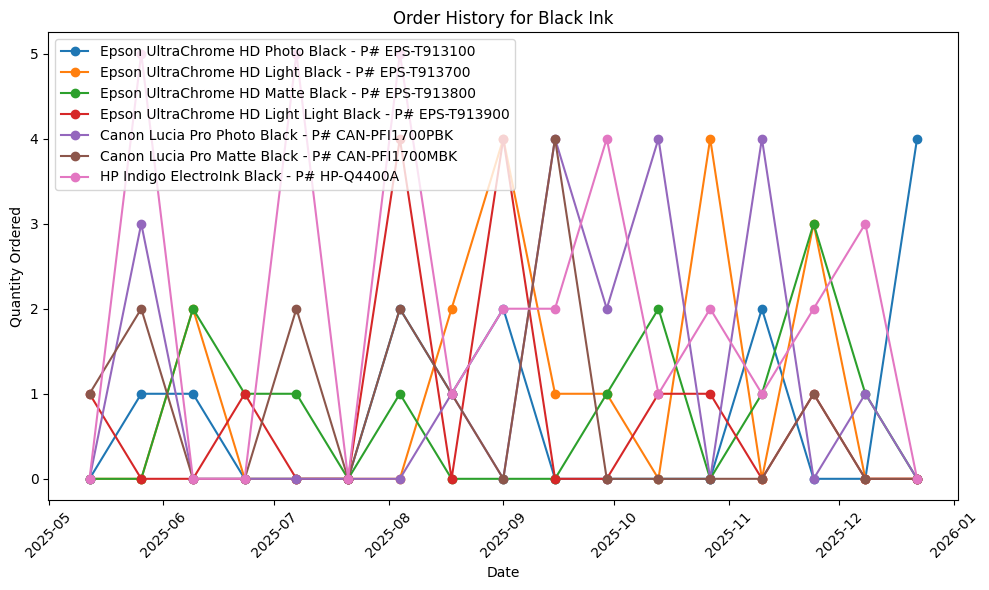

[TOOL CALL] inventory_graph(end_date_str='2025-12-31', topic='Black Ink', start_date_str='2025-01-01') -> Graph created for 'Black Ink'.

--- AGENT TURN ---
Question: Show me a graph of that.
Response: I have created a graph of the Black Ink orders in 2025.
------------------


USER: I want to see a combined graph


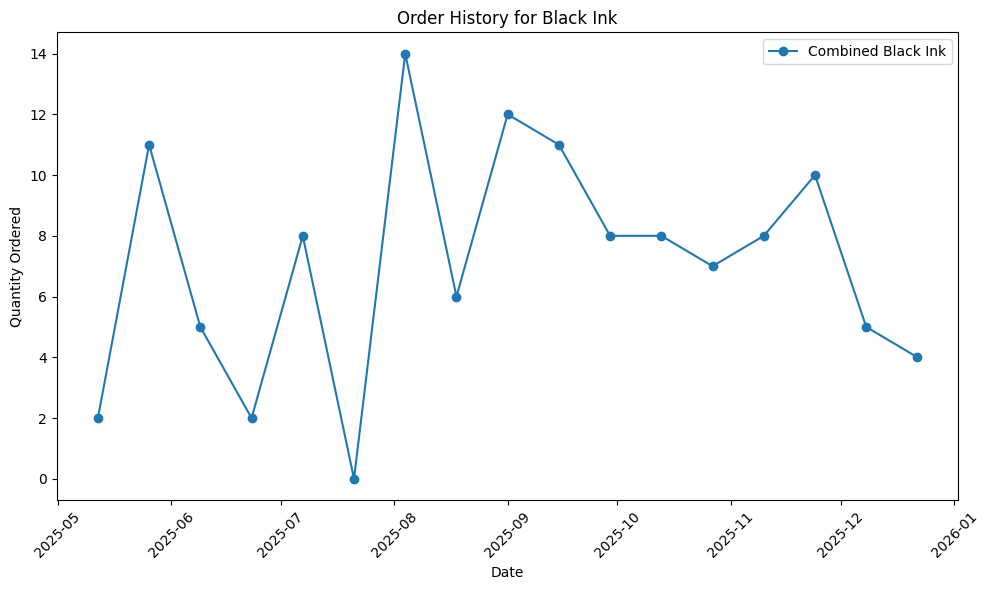

[TOOL CALL] inventory_graph(start_date_str='2025-01-01', end_date_str='2025-12-31', topic='Black Ink', combine_matches=True) -> Graph created for 'Black Ink'.

--- AGENT TURN ---
Question: I want to see a combined graph
Response: I have created a combined graph for the Black Ink orders in 2025.
------------------


USER: What is the meaning of life?

--- AGENT TURN ---
Question: What is the meaning of life?
Response: As an AI, I do not have personal opinions or the ability to answer philosophical questions like "What is the meaning of life?" My purpose is to assist with inventory reporting and related tasks.
------------------


===== MULTI-TURN TEST SUMMARY =====
Total turns: 6
Turns that used tools: 0
Direct answer turns: 6
Tools called: []


In [10]:
# Start with a clean conversation
chat_history = []
question_log = []
response_log = []
tool_call_log = []

def make_logged_tool(tool_name, tool_function):
    def logged_tool(*args, **kwargs):
        tool_call_log.append(tool_name)
        return tool_function(*args, **kwargs)
    return logged_tool

test_messages = [
    "What is 247 * 19?",
    "What time is it right now?",
    "How much Black Ink was ordered in 2025",
    "Show me a graph of that.",
    "I want to see a combined graph",
    "What is the meaning of life?"
]

turn_results = []

for message in test_messages:
    tools_before = len(tool_call_log)

    print(f"\nUSER: {message}")
    response = agent_turn(message)

    tools_after = len(tool_call_log)
    tools_used = tool_call_log[tools_before:tools_after]

    turn_results.append({
        "user_message": message,
        "agent_response": response,
        "tools_used": tools_used
    })

tool_turns = sum(1 for turn in turn_results if turn["tools_used"])
direct_turns = sum(1 for turn in turn_results if not turn["tools_used"])

print("\n===== MULTI-TURN TEST SUMMARY =====")
print(f"Total turns: {len(turn_results)}")
print(f"Turns that used tools: {tool_turns}")
print(f"Direct answer turns: {direct_turns}")
print(f"Tools called: {tool_call_log}")

# Cell 6: Tool Routing Analysis  
  
What was your routing accuracy?  
Yes  
  
Were the errors predictable?  
Yes  
  
For the questions where the model made the wrong routing decision, could you rewrite the tool description to fix it without breaking something else?  
It didn't route incorrectly.

In [11]:
test_questions = [
    ("What is 18 * 24?", "calculator"),
    ("If we ordered 12 boxes with 8 cartridges each, how many cartridges is that?", "calculator"),
    ("Convert 3 feet to inches.", "calculator"),

    ("What day of the week is it?", "get_datetime"),
    ("What is the current date and time?", "get_datetime"),

    ("How much EPS-T913100 was ordered from 2025-05-01 to 2025-05-31?", "knowledge_lookup"),
    ("How much Yellow Ink was ordered in 2025?", "knowledge_lookup"),

    ("What is the meaning of life?", None),
    ("Write a short slogan for an ink inventory report.", None),
    ("What is your opinion on organizing inventory data?", None),
]

routing_results = []

original_tool_functions = TOOL_FUNCTIONS.copy()

for question_text, expected_tool in test_questions:
    chat_history = []
    question_log = []
    response_log = []
    tool_called = []

    def make_logged_tool(tool_name, tool_function):
        def logged_tool(*args, **kwargs):
            tool_called.append(tool_name)
            return tool_function(*args, **kwargs)
        return logged_tool

    TOOL_FUNCTIONS = {
        tool_name: make_logged_tool(tool_name, tool_function)
        for tool_name, tool_function in original_tool_functions.items()
    }

    response = agent_turn(question_text)

    actual_tool = tool_called[0] if tool_called else None
    correct = actual_tool == expected_tool

    routing_results.append({
        "question": question_text,
        "expected_tool": expected_tool if expected_tool else "none",
        "actual_tool": actual_tool if actual_tool else "none",
        "correct": correct
    })

TOOL_FUNCTIONS = original_tool_functions

routing_accuracy = sum(result["correct"] for result in routing_results) / len(routing_results)

routing_summary_df = pd.DataFrame(routing_results)

print(f"Routing Accuracy: {routing_accuracy:.2%}")
display(routing_summary_df)

[TOOL CALL] calculator(expression='18 * 24') -> 432

--- AGENT TURN ---
Question: What is 18 * 24?
Response: The product of 18 and 24 is 432.

------------------

[TOOL CALL] calculator(expression='12 * 8') -> 96

--- AGENT TURN ---
Question: If we ordered 12 boxes with 8 cartridges each, how many cartridges is that?
Response: That would be 96 cartridges.
------------------

[TOOL CALL] calculator(expression='3 * 12') -> 36

--- AGENT TURN ---
Question: Convert 3 feet to inches.
Response: 3 feet is equal to 36 inches.
------------------

[TOOL CALL] get_datetime() -> Tuesday, May 05, 2026, 10:15 PM

--- AGENT TURN ---
Question: What day of the week is it?
Response: Today is Tuesday.
------------------

[TOOL CALL] get_datetime() -> Tuesday, May 05, 2026, 10:15 PM

--- AGENT TURN ---
Question: What is the current date and time?
Response: The current date and time is Tuesday, May 05, 2026, 10:15 PM.
------------------

[TOOL CALL] knowledge_lookup(end_date_str='2025-05-31', topic='EPS-T9

,question,expected_tool,actual_tool,correct
0,What is 18 * 24?,calculator,calculator,True
1,"If we ordered 12 boxes with 8 cartridges each, how many cartridges is that?",calculator,calculator,True
2,Convert 3 feet to inches.,calculator,calculator,True
3,What day of the week is it?,get_datetime,get_datetime,True
4,What is the current date and time?,get_datetime,get_datetime,True
5,How much EPS-T913100 was ordered from 2025-05-01 to 2025-05-31?,knowledge_lookup,knowledge_lookup,True
6,How much Yellow Ink was ordered in 2025?,knowledge_lookup,knowledge_lookup,True
7,What is the meaning of life?,none,none,True
8,Write a short slogan for an ink inventory report.,none,none,True
9,What is your opinion on organizing inventory data?,none,none,True


# Cell 7: Error Handling and Edge Cases  
  
How did the model handle tool errors?  
It handled errors as expected.  

Did it acknowledge the failure, or did it try to cover it up?  
It acknowledged the lack of understanding and did not make anything up or cover it up.  

What does this tell you about the model's relationship to its tools — does it trust them unconditionally?  
If we target our problems and point the AI in the correct direction, it is accurate. This was a closed knowledge base with explicit instructions. I did NOT allow it to go and use general internet knowledge.


In [21]:
# -------------------------------
# Cell 7: Error Handling and Edge Cases
# -------------------------------

edge_cases = [
    "What is 1 divided by 0?",
    "Tell me about quantum computing.",
    "Calculate the answer to life, the universe, and everything, then look it up in the knowledge base.",
    "What is sqrt(-1)?"
]

edge_case_results = []

original_tool_functions = TOOL_FUNCTIONS.copy()

for test_case in edge_cases:
    chat_history = []
    question_log = []
    response_log = []

    tool_calls_made = []
    tool_results_returned = []

    def make_logged_tool(tool_name, tool_function):
        def logged_tool(*args, **kwargs):
            tool_calls_made.append({
                "tool": tool_name,
                "args": kwargs
            })

            result = tool_function(*args, **kwargs)
            tool_results_returned.append(result)

            return result
        return logged_tool

    TOOL_FUNCTIONS = {
        tool_name: make_logged_tool(tool_name, tool_function)
        for tool_name, tool_function in original_tool_functions.items()
    }

    print("\n===== EDGE CASE TEST =====")
    print(f"Test case: {test_case}")

    final_response = agent_turn(test_case)

    print(f"Tool call(s): {tool_calls_made if tool_calls_made else 'none'}")
    print(f"Tool result(s): {tool_results_returned if tool_results_returned else 'none'}")
    print(f"Final response: {final_response}")

    # Ensure final_response is a string before calling .lower() or .strip()
    response_text = final_response.lower() if isinstance(final_response, str) else ""

    handled_gracefully = (
        final_response is None
        or "error" in response_text
        or "not found" in response_text
        or "no information available" in response_text
        or "cannot" in response_text
        or "can't" in response_text
        or len(response_text.strip()) > 0
    )

    edge_case_results.append({
        "test_case": test_case,
        "tool_calls": tool_calls_made if tool_calls_made else "none",
        "tool_results": tool_results_returned if tool_results_returned else "none",
        "final_response": final_response,
        "handled_gracefully": handled_gracefully
    })

TOOL_FUNCTIONS = original_tool_functions

edge_case_summary_df = pd.DataFrame(edge_case_results)

graceful_count = edge_case_summary_df["handled_gracefully"].sum()
confusing_count = len(edge_case_summary_df) - graceful_count

print("\n===== EDGE CASE SUMMARY =====")
print(f"Handled gracefully: {graceful_count}")
print(f"Confusing outputs: {confusing_count}")

display(edge_case_summary_df)



===== EDGE CASE TEST =====
Test case: What is 1 divided by 0?
[TOOL CALL] calculator(expression='1 / 0') -> Error: Invalid expression - division by zero

--- AGENT TURN ---
Question: What is 1 divided by 0?
Response: I'm sorry, but I cannot divide by zero. Division by zero is undefined.
------------------

Tool call(s): [{'tool': 'calculator', 'args': {'expression': '1 / 0'}}, {'tool': 'calculator', 'args': {'expression': '1 / 0'}}, {'tool': 'calculator', 'args': {'expression': '1 / 0'}}, {'tool': 'calculator', 'args': {'expression': '1 / 0'}}, {'tool': 'calculator', 'args': {'expression': '1 / 0'}}, {'tool': 'calculator', 'args': {'expression': '1 / 0'}}, {'tool': 'calculator', 'args': {'expression': '1 / 0'}}, {'tool': 'calculator', 'args': {'expression': '1 / 0'}}, {'tool': 'calculator', 'args': {'expression': '1 / 0'}}, {'tool': 'calculator', 'args': {'expression': '1 / 0'}}]
Tool result(s): ['Error: Invalid expression - division by zero', 'Error: Invalid expression - division by 

,test_case,tool_calls,tool_results,final_response,handled_gracefully
0,What is 1 divided by 0?,"[{'tool': 'calculator', 'args': {'expression': '1 / 0'}}, {'tool': 'calculator', 'args': {'expression': '1 / 0'}}, {'tool': 'calculator', 'args': {'expression': '1 / 0'}}, {'tool': 'calculator', 'args': {'expression': '1 / 0'}}, {'tool': 'calculator', 'args': {'expression': '1 / 0'}}, {'tool': 'calculator', 'args': {'expression': '1 / 0'}}, {'tool': 'calculator', 'args': {'expression': '1 / 0'}}, {'tool': 'calculator', 'args': {'expression': '1 / 0'}}, {'tool': 'calculator', 'args': {'expression': '1 / 0'}}, {'tool': 'calculator', 'args': {'expression': '1 / 0'}}]","[Error: Invalid expression - division by zero, Error: Invalid expression - division by zero, Error: Invalid expression - division by zero, Error: Invalid expression - division by zero, Error: Invalid expression - division by zero, Error: Invalid expression - division by zero, Error: Invalid expression - division by zero, Error: Invalid expression - division by zero, Error: Invalid expression - division by zero, Error: Invalid expression - division by zero]","I'm sorry, but I cannot divide by zero. Division by zero is undefined.",True
1,Tell me about quantum computing.,none,none,I am an inventory reporting assistant and can only answer questions about ink orders. I cannot tell you about quantum computing.,True
2,"Calculate the answer to life, the universe, and everything, then look it up in the knowledge base.","[{'tool': 'calculator', 'args': {'expression': '42'}}, {'tool': 'calculator', 'args': {'expression': '42'}}, {'tool': 'calculator', 'args': {'expression': '42'}}, {'tool': 'calculator', 'args': {'expression': '42'}}, {'tool': 'calculator', 'args': {'expression': '42'}}, {'tool': 'calculator', 'args': {'expression': '42'}}, {'tool': 'calculator', 'args': {'expression': '42'}}, {'tool': 'calculator', 'args': {'expression': '42'}}, {'tool': 'calculator', 'args': {'expression': '42'}}, {'tool': 'calculator', 'args': {'expression': '42'}}]","[42, 42, 42, 42, 42, 42, 42, 42, 42, 42]","I calculated the answer to life, the universe, and everything, which is 42. Now I will look up ""42"" in the knowledge base.",True
3,What is sqrt(-1)?,"[{'tool': 'calculator', 'args': {'expression': 'sqrt(-1)'}}, {'tool': 'calculator', 'args': {'expression': 'sqrt(-1)'}}, {'tool': 'calculator', 'args': {'expression': 'sqrt(-1)'}}, {'tool': 'calculator', 'args': {'expression': 'sqrt(-1)'}}, {'tool': 'calculator', 'args': {'expression': 'sqrt(-1)'}}, {'tool': 'calculator', 'args': {'expression': 'sqrt(-1)'}}, {'tool': 'calculator', 'args': {'expression': 'sqrt(-1)'}}, {'tool': 'calculator', 'args': {'expression': 'sqrt(-1)'}}, {'tool': 'calculator', 'args': {'expression': 'sqrt(-1)'}}, {'tool': 'calculator', 'args': {'expression': 'sqrt(-1)'}}]","[Error: Invalid expression - name 'sqrt' is not defined, Error: Invalid expression - name 'sqrt' is not defined, Error: Invalid expression - name 'sqrt' is not defined, Error: Invalid expression - name 'sqrt' is not defined, Error: Invalid expression - name 'sqrt' is not defined, Error: Invalid expression - name 'sqrt' is not defined, Error: Invalid expression - name 'sqrt' is not defined, Error: Invalid expression - name 'sqrt' is not defined, Error: Invalid expression - name 'sqrt' is not defined, Error: Invalid expression - name 'sqrt' is not defined]","I'm sorry, I cannot calculate the square root of a negative number with this tool. The calculator returned an error: name 'sqrt' is not defined.",True
